# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2383 Борисов Иван Вадимович и Сыздыков Нургалым Конакбаевич. Вариант №25

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.


## Краткое изложение основных теоретических понятий

**Генеральная совокупность** - это полное множество всех объектов, людей или событий, объединенных общими признаками, которые подлежат исследованию. 

**Выборочная совокупность** - часть объектов из генеральной совокупности, отобранных для изучения, с тем чтобы сделать заключение о всей генеральной совокупности. 

**Статистический ряд** - последовательность элементов выборки, расположенных в порядке их получения (наблюдения).

**Ранжированный ряд** - последовательность элементов выборки, расположенных в порядке возрастания их значений. Номер элемента ранжированного ряда в последовательности называется **рангом**.

**Вариационный ряд** - получается из ранжированного ряда в результате объединения одинаковых элементов. Элементы вариационного ряда называются вариантами. 

**Частота** - число, показывающее, сколько раз повторяется варианта.

Если количество вариант *К* достаточно велико, то необходимо разделять вариационный ряд на интервалы. В этом случае ряд называется **интервальным**. 

Количество интервалов *k* зависит от объема выборки *N* и может быть вычислено *по формуле Стерджесса*:

$$k=1 + 3.31 \cdot \lg N$$

Полученное значение округляется до целого.
Рекомендуется выбирать нечетное количество интервалов. 

Затем вычисляется ширина интервала *h* по формуле:

$$h=\dfrac{x_{max} - x_{min}}{k}$$

## Постановка задачи с кратким описанием порядка выполнения работы

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.


### Порядок выполнения работы

1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.
2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.
3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.
4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.
5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.
6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.



### 1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.

In [6]:
!python --version

Python 3.14.2


В качестве языка программирования был выбран Python 3.14.2, т.к. как он поддерживает большое количество библиотек для работы с данными.


В качестве среды разработки был выбран JupyterLab.

### 2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.

Двумерная генеральная совокупность была предложена преподавателем.

Доступна по следующей ссылке:

[Данные наблюдения относительно объемного веса ν (г/см³) при влажности 10% и модуля упругости E (кг/см²) при сжатии вдоль волокон древесины резонансной ели (csv-формат).](https://se.moevm.info/lib/exe/fetch.php/courses:statistical_methods_of_experimental_data_handling:sample.zip)

### 3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.

Выборка была сформирована из генеральной совокупности с помощью `df.sample(116)`, согласно варианту в таблице. 

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

In [4]:
data = pd.read_csv('Syzdykov_Borisov_data_116.csv')

In [5]:
data

,nu,E
0,396,90.1
1,525,145.3
2,437,129.4
3,411,115.2
4,510,124.1
...,...,...
111,463,144.9
112,487,146.0
113,528,163.4
114,331,74.1


### 4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.

In [60]:
def process_statistical_series(data: pd.DataFrame, feature_name: str):
    series = data[feature_name]
    print(f"--- Анализ признака: {feature_name} ---")
    
    # 1. Ранжированный ряд
    ranked_series = series.sort_values(ignore_index=True)
    print(f"Ранжированный ряд:")
    print(ranked_series)
    
    # 2. Вариационный ряд
    variation_series = series.value_counts().sort_index()
    print(f"Вариационный ряд:")
    print(variation_series)
    
    # 3. Интервальный ряд
    n = len(series)
    x_min, x_max = series.min(), series.max()
    
    k = int(np.ceil(1 + 3.31 * np.log10(n)))
    h = (x_max - x_min) / k

    print(f"Минимальное значение: {x_min}")
    print(f"Максимальное значение: {x_max}")
    print(f"Оптимальное число интервалов (k): {k}")
    print(f"Шаг интервала (h): {h:.4f}")
    
    # Расчет границ интервалов
    bins = [x_min + i * h for i in range(k + 1)]
    
    # Подсчет частот
    mi, edges = np.histogram(series, bins=bins)
    xi_mid = (edges[:-1] + edges[1:]) / 2
    
    rel_mi = mi / n
    cum_mi = np.cumsum(mi)
    cum_rel_mi = np.cumsum(rel_mi)
    
    intervals_str = [f"[{edges[i]:.2f}, {edges[i+1]:.2f})" if i != k - 1 else f"[{edges[i]:.2f}, {edges[i+1]:.2f}]" for i in range(k)]
    indices = list(range(1, k + 1))
    
    table_df = pd.DataFrame({
        'i': indices,
        '[xi, xi+1)': intervals_str,
        '~xi': np.round(xi_mid, 2),
        'mi': mi,
        '~mi': np.round(rel_mi, 4),
        'mнакi': cum_mi,
        '~mнакi': np.round(cum_rel_mi, 4)
    })
    
    sum_row = pd.DataFrame({
        'i': ['Σ'],
        '[xi, xi+1)': ['-'],
        '~xi': ['-'],
        'mi': [mi.sum()],
        '~mi': [np.round(rel_mi.sum(), 4)],
        'mнакi': ['-'],
        '~mнакi': ['-']
    })
    
    final_table = pd.concat([table_df, sum_row], ignore_index=True)
    
    return final_table, edges, xi_mid, mi, rel_mi, cum_mi, cum_rel_mi, h


def plot_distributions(edges, midpoints, freqs, cum_freqs, width, is_relative=False, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # Настройки стилей в зависимости от типа частоты
    c_bar = 'lightcoral' if not is_relative else 'mediumaquamarine'
    c_line = 'darkred' if not is_relative else 'teal'
    y_label = 'Абсолютная частота ($m_i$)' if not is_relative else 'Относительная частота ($\\tilde{m}_i$)'
    cum_y_label = 'Накопленная абс. частота' if not is_relative else 'Накопленная отн. частота'
    
    # 1. Гистограмма
    ax[0].bar(midpoints, freqs, width=width*0.9, color=c_bar, edgecolor='black', alpha=0.8)
    ax[0].set_title('Гистограмма')
    ax[0].set_xlabel('Значения признака')
    ax[0].set_ylabel(y_label)
    ax[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    # 2. Полигон
    ax[1].plot(midpoints, freqs, marker='s', color=c_line, linestyle='-', linewidth=2, markersize=6)
    ax[1].set_title('Полигон частот')
    ax[1].set_xlabel('Значения признака')
    ax[1].set_ylabel(y_label)
    ax[1].grid(linestyle='--', alpha=0.5)
    
    # 3. Эмпирическая функция распределения
    x_steps = list(edges)
    y_steps = [0] + list(cum_freqs)
    ax[2].step(x_steps, y_steps, where='post', color=c_line, linewidth=2)
    ax[2].plot(x_steps[1:], cum_freqs, 'o', color=c_line, markersize=5)
    ax[2].set_title('Эмпирическая функция')
    ax[2].set_xlabel('Значения признака')
    ax[2].set_ylabel(cum_y_label)
    ax[2].grid(linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [61]:
table_nu, edges_nu, mid_nu, mi_nu, rel_mi_nu, cum_nu, cum_rel_nu, h_nu = process_statistical_series(
    data, "nu"
)
display(table_nu)

--- Анализ признака: nu ---
Ранжированный ряд:
0      320
1      330
2      331
3      345
4      351
      ... 
111    550
112    569
113    585
114    591
115    623
Name: nu, Length: 116, dtype: int64
Вариационный ряд:
nu
320    1
330    1
331    1
345    1
351    1
      ..
550    1
569    1
585    1
591    1
623    1
Name: count, Length: 91, dtype: int64
Минимальное значение: 320
Максимальное значение: 623
Оптимальное число интервалов (k): 8
Шаг интервала (h): 37.8750


,i,"[xi, xi+1)",~xi,mi,~mi,mнакi,~mнакi
0,1,"[320.00, 357.88)",338.94,7,0.0603,7,0.0603
1,2,"[357.88, 395.75)",376.81,9,0.0776,16,0.1379
2,3,"[395.75, 433.62)",414.69,22,0.1897,38,0.3276
3,4,"[433.62, 471.50)",452.56,33,0.2845,71,0.6121
4,5,"[471.50, 509.38)",490.44,26,0.2241,97,0.8362
5,6,"[509.38, 547.25)",528.31,14,0.1207,111,0.9569
6,7,"[547.25, 585.12)",566.19,3,0.0259,114,0.9828
7,8,"[585.12, 623.00]",604.06,2,0.0172,116,1.0
8,Σ,-,-,116,1.0000,-,-


Из построенного ранжированного ряда видно, что значения признака варьируются от 320 до 623. 

Интервальный ряд разбит на 8 интервалов. 

Наибольшая концентрация значений наблюдается в интервале [433.62, 471.50) — в него попадает 33 наблюдений (28% от выборки).

In [62]:
table_e, edges_e, mid_e, mi_e, rel_mi_e, cum_e, cum_rel_e, h_e = process_statistical_series(data, "E")

display(table_e)

--- Анализ признака: E ---
Ранжированный ряд:
0       71.1
1       71.9
2       72.6
3       73.4
4       74.1
       ...  
111    164.0
112    164.4
113    169.9
114    177.7
115    195.7
Name: E, Length: 116, dtype: float64
Вариационный ряд:
E
71.1     1
71.9     1
72.6     1
73.4     1
74.1     1
        ..
164.0    1
164.4    1
169.9    1
177.7    1
195.7    1
Name: count, Length: 108, dtype: int64
Минимальное значение: 71.1
Максимальное значение: 195.7
Оптимальное число интервалов (k): 8
Шаг интервала (h): 15.5750


,i,"[xi, xi+1)",~xi,mi,~mi,mнакi,~mнакi
0,1,"[71.10, 86.67)",78.89,6,0.0517,6,0.0517
1,2,"[86.67, 102.25)",94.46,10,0.0862,16,0.1379
2,3,"[102.25, 117.82)",110.04,15,0.1293,31,0.2672
3,4,"[117.82, 133.40)",125.61,34,0.2931,65,0.5603
4,5,"[133.40, 148.97)",141.19,34,0.2931,99,0.8534
5,6,"[148.97, 164.55)",156.76,14,0.1207,113,0.9741
6,7,"[164.55, 180.12)",172.34,2,0.0172,115,0.9914
7,8,"[180.12, 195.70]",187.91,1,0.0086,116,1.0
8,Σ,-,-,116,1.0000,-,-


Минимальное значение составляет 71.1, максимальное — 195.7. Два одинаковых по частоте интервала оказались самыми частотными, вместившими в себя 34 элементов выборки. Крайние интервалы ожидаемо содержат минимальное количество значений.

### 5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.
### 6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

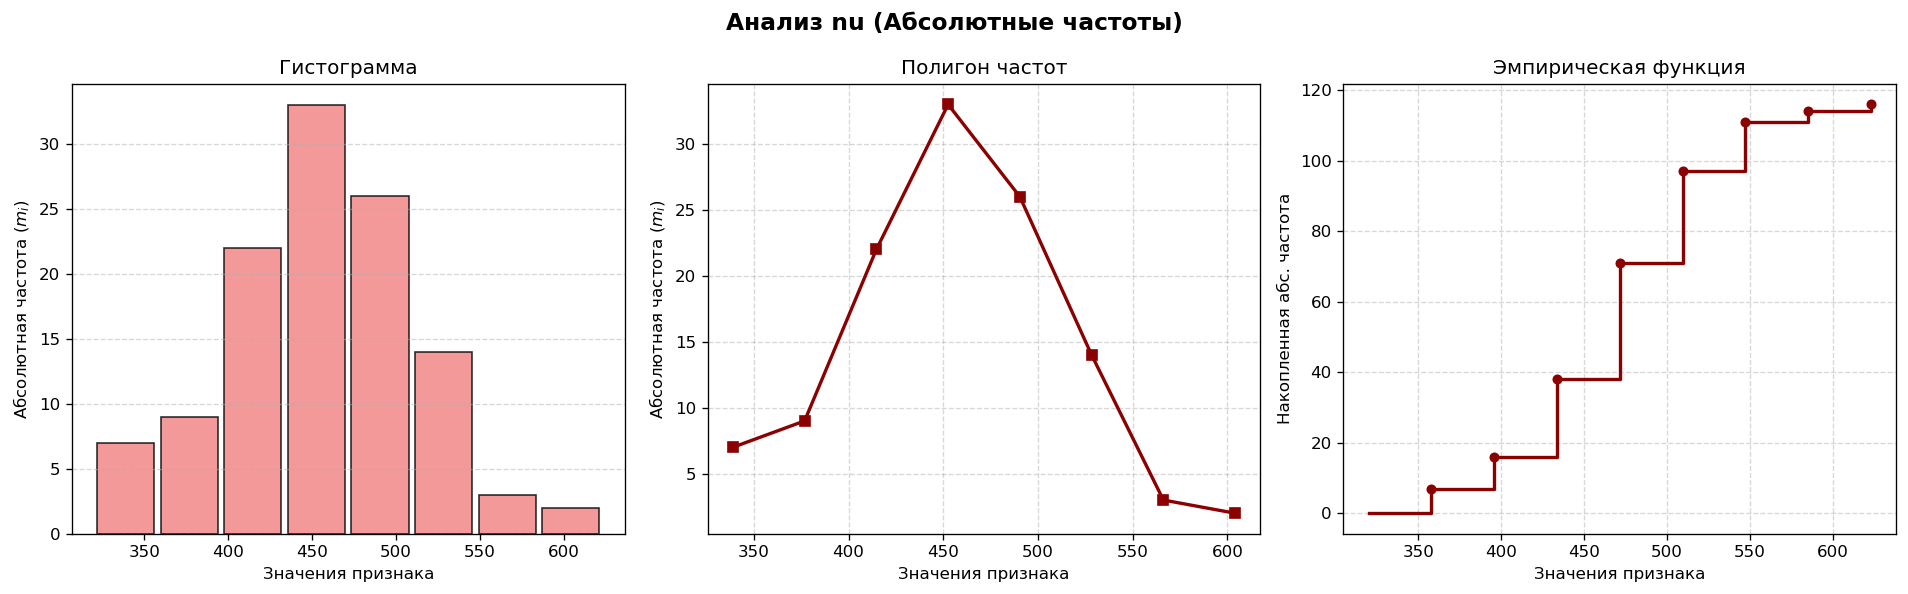

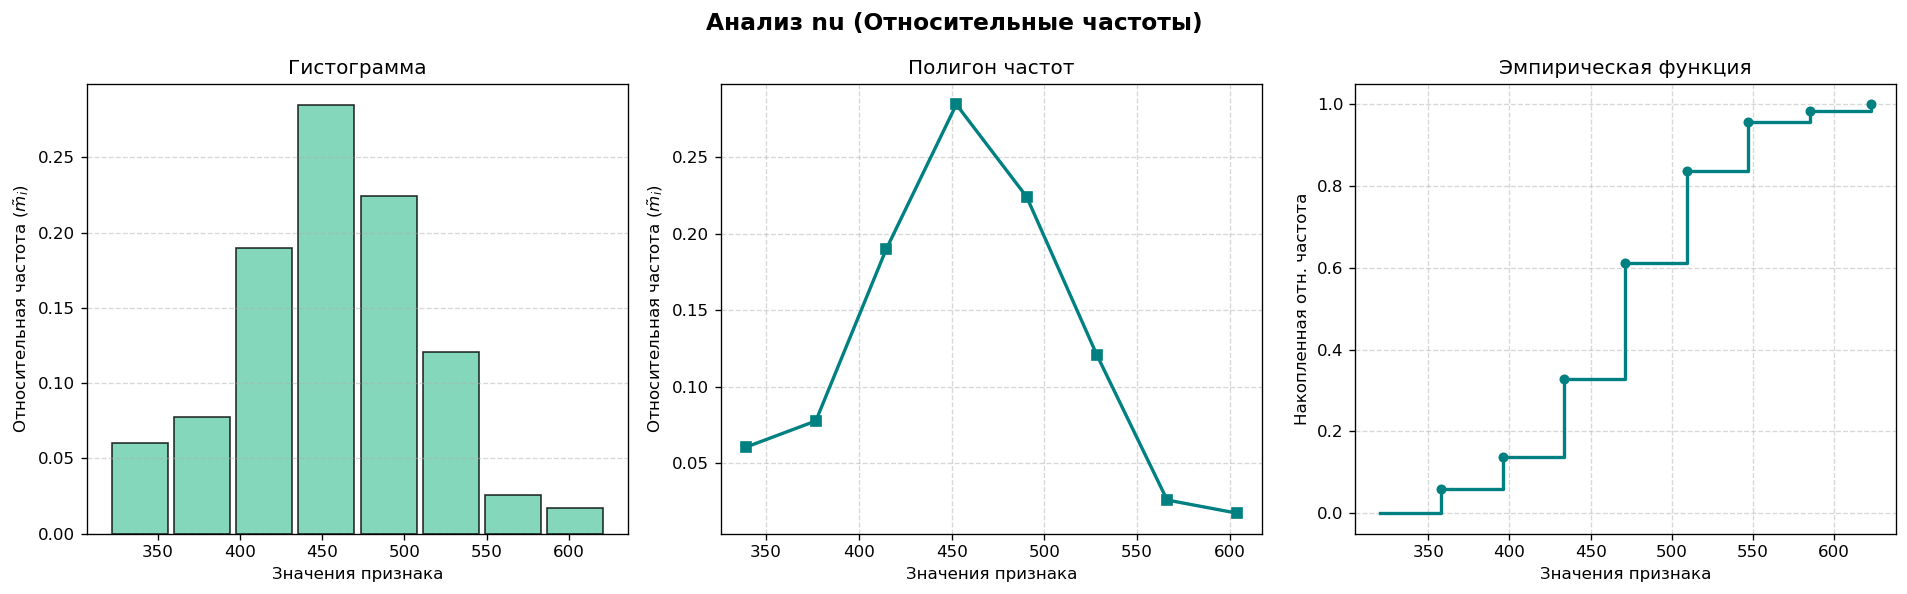

In [54]:
plot_distributions(edges_nu, mid_nu, mi_nu, cum_nu, h_nu, is_relative=False, title="Анализ nu (Абсолютные частоты)")
plot_distributions(edges_nu, mid_nu, rel_mi_nu, cum_rel_nu, h_nu, is_relative=True, title="Анализ nu (Относительные частоты)")

Визуально графики абсолютных и относительных частот идентичны по своей структуре и профилю распределения, отличаясь исключительно масштабом оси ординат. Распределение имеет симметричный вид. Гистограмма и полигон наглядно демонстрируют модальный интервал, а график эмпирической функции иллюстрирует скорость 
накопления частот: наиболее резкий скачок функции происходит именно в центральных (наиболее густонаселенных) интервалах.

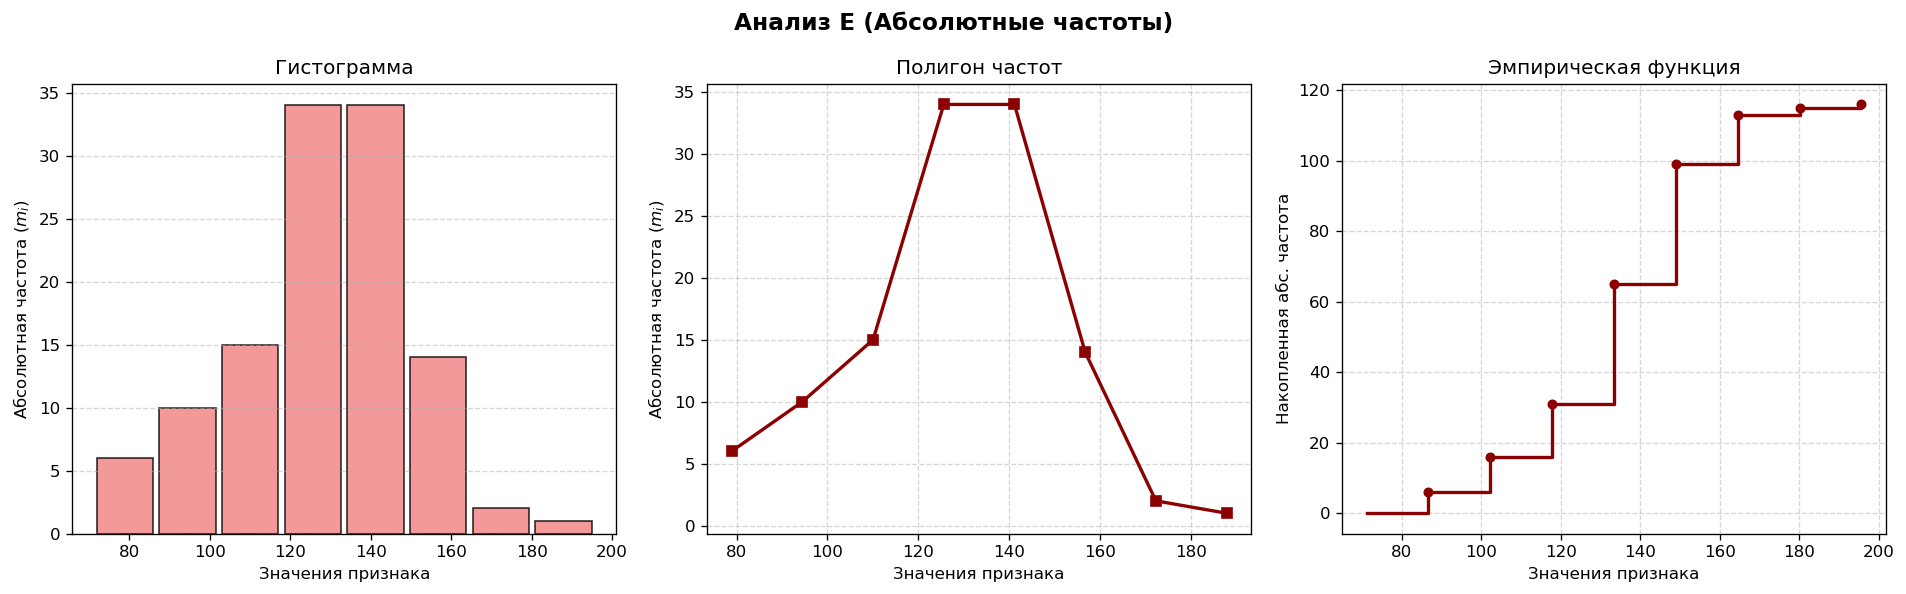

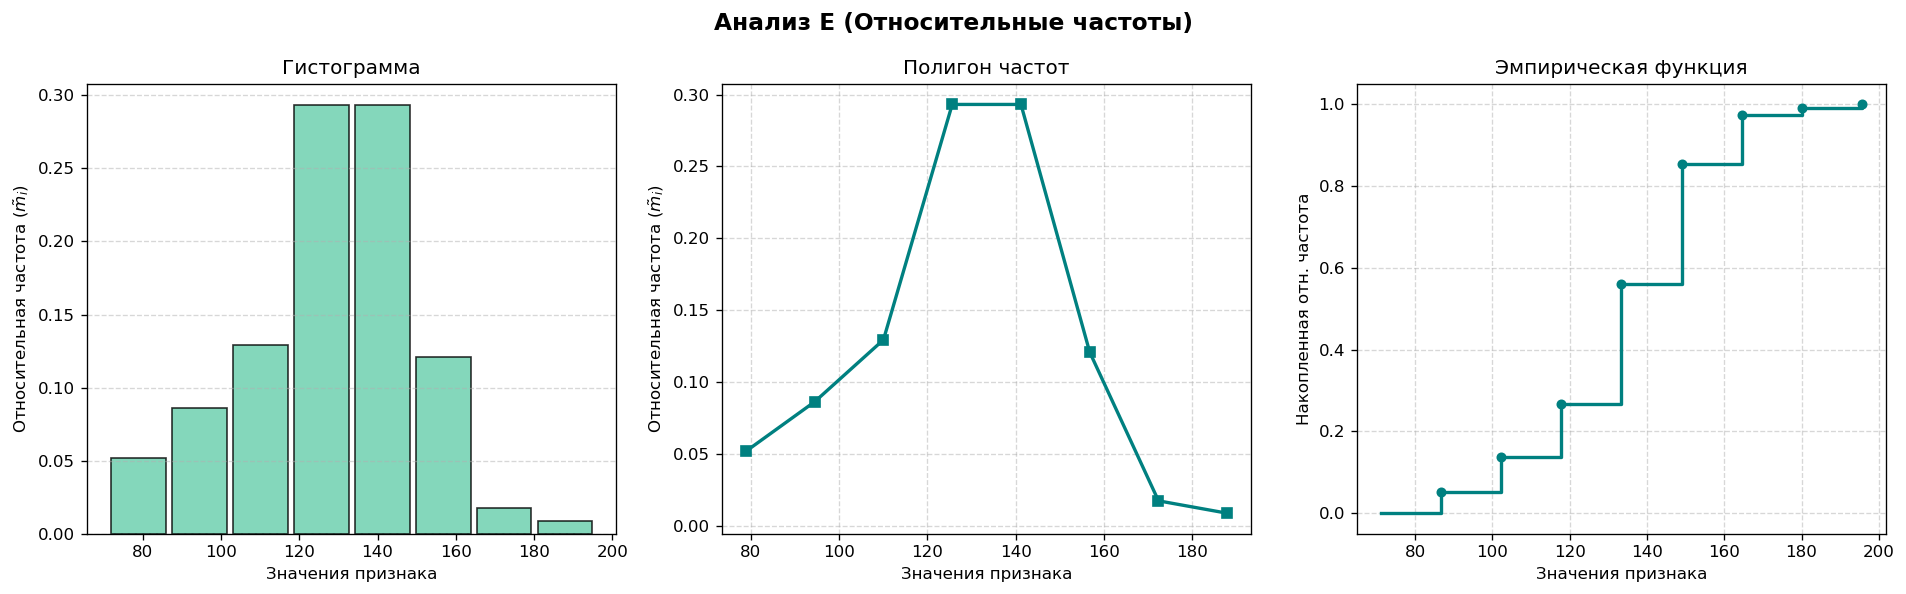

In [49]:
plot_distributions(edges_e, mid_e, mi_e, cum_e, h_e, is_relative=False, title="Анализ E (Абсолютные частоты)")
plot_distributions(edges_e, mid_e, rel_mi_e, cum_rel_e, h_e, is_relative=True, title="Анализ E (Относительные частоты)")

Аналогично первому признаку, разница между графиками заключается лишь в единицах измерения. Распределение переменной E имеет ярко выраженный пик. 
Ступенчатый график эмпирической функции демонстрирует плавный рост по краям и крутой подъем в области центральных значений. Более того, для переменной E окзалось так, что два интервала имеют одинаковые наибольшие значения частоты.

### Выводы

В ходе выполнения практической работы были успешно закреплены навыки программной обработки экспериментальных данных. Из генеральной совокупности согласно варианту была извлечена случайная выборка объемом 116 элементов. С помощью библиотеки pandas были программно реализованы алгоритмы построения ранжированного, вариационного и интервального рядов.

Использование формулы Стерджесса позволило оптимально разбить данные на интервалы. Формирование таблицы заданного стандарта подтвердило корректность расчетов (сумма относительных частот $\sum \tilde{m_i}$​=1). Построенные визуализации (гистограммы, полигоны частот и эмпирические функции распределения) позволили наглядно оценить характер распределения случайных величин, выявить модальные интервалы и оценить симметричность данных в выборке. Полученные результаты могут служить надежной основой для дальнейшего глубокого статистического анализа (проверки гипотез, поиска корреляций).